In [1]:
import matplotlib.pyplot as plt
import pandas as pd

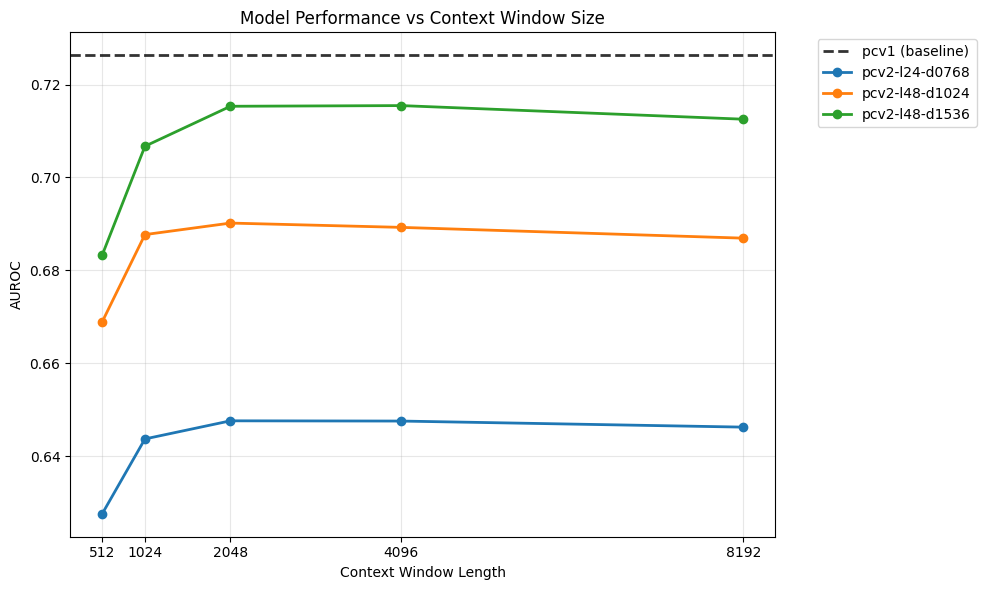

In [2]:
data = {
   'model': ['pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536', 'pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536',
             'pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536', 'pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536',
             'pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536', 'pcv1'],
   'context': [512, 512, 512, '1k', '1k', '1k', '2k', '2k', '2k', '4k', '4k', '4k', '8k', '8k', '8k', 512],
   'roc_auc': [0.627571, 0.668908, 0.683297, 0.643690, 0.687693, 0.706721, 0.647592, 0.690174, 0.715326,
               0.647540, 0.689246, 0.715472, 0.646234, 0.686926, 0.712541, 0.726310]
}

df = pd.DataFrame(data)

context_map = {'1k': 1024, '2k': 2048, '4k': 4096, '8k': 8192}
df['context_numeric'] = df['context'].replace(context_map)

plt.figure(figsize=(10, 6))

baseline_auroc = df[df['model'] == 'pcv1']['roc_auc'].iloc[0]

# Plot horizontal baseline
plt.axhline(y=baseline_auroc, color='black', linestyle='--', linewidth=2, 
           label='pcv1 (baseline)', alpha=0.8)

# Plot other models
other_models = df[df['model'] != 'pcv1']
models = other_models['model'].unique()

for model in models:
   model_data = other_models[other_models['model'] == model]
   plt.plot(model_data['context_numeric'], model_data['roc_auc'], 
           marker='o', linewidth=2, markersize=6, label=model)

plt.xlabel('Context Window Length')
plt.ylabel('AUROC')
plt.title('Model Performance vs Context Window Size')
plt.xticks([512, 1024, 2048, 4096, 8192])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_vs_context_window.pdf', format='pdf', bbox_inches='tight')
plt.show()